# S3b_SnowModel_TUOL_scenarios.ipynb
This notebook compares the SnowModel distributed scenarios at across Tuolumne

For additional details see ../postprocess/paper/fig_3_distributed_bias_correction_domain_match.ipynb
                           ../postprocess/paper/fig_3_distributed_bias_correction_domain_match_viz.ipynb



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import os
import importlib
import sys
import rioxarray as rxr
from pathlib import Path
import xarray as xr


# gets rid of a lot of annoying warnings, we know there are NaNs (might want to remove this to double check)
import warnings
warnings.filterwarnings("ignore")


In [2]:
sys.path.insert(1, '../scripts/')

In [3]:
import metadata as metadata


In [4]:
import importlib
importlib.reload(metadata)


<module 'metadata' from '/glade/u/home/rossamower/school/uw/cues_git/cues_sentinel_snowmodel/python/supporting_information/../scripts/metadata.py'>

# Load Data

## Metadata

### point locations

In [5]:
importlib.reload(metadata)
# tuolumne.
tuolumne_cfg = metadata.load_yaml(Path(f"../../configs/Tuolumne.yaml"))


### polygon geometries

In [6]:
importlib.reload(metadata)
# tuolumne
tuolumne_geog_fpath,aso_crs = metadata.get_shapefile_fpath(tuolumne_cfg,"shapefile_fpath","zoom_1")
# read shapefile
## tuolumne
tuolumne_geog_gdf = gpd.read_file(tuolumne_geog_fpath)
tuolumne_proj_gdf = tuolumne_geog_gdf.to_crs(f'EPSG:{aso_crs}')


## ASO

In [7]:
aso_spatial_ds = xr.load_dataset('/glade/u/home/rossamower/rmower/pixel/aso/ASO_50M_SWE_SPATIAL.nc')

In [8]:
def match_aso_da(sm_ds: xr.Dataset,
                 aso_ds: xr.Dataset,
                 geog_ds: xr.Dataset,
                 date_str: str,
                 var: str,
                 shape_crs: str,
                 shape_proj_gdf: gpd.GeoDataFrame,
                 ):

    # create date array.
    date_arry = np.array([f'{date_str[0:4]}-{date_str[4:6]}-{date_str[6:8]}'],dtype = np.datetime64)
    # create mask based on aso date.
    mask_aso = (aso_ds.where(aso_ds.date == date_arry,drop = True)['aso_swe'] >= 0).values
    # reshape snowmodel.
    arry = sm_ds[var].values
    # set negative values to zero.
    if var == 'swed':
        arry = arry.copy()
        arry[arry < 0] = 0.0
    # create xarray object.
    da_sm = xr.DataArray(
        data=arry[:,::-1,:],
        dims=["date","y", "x"],
        coords=dict(
            date=(["date"], date_arry),
            y=(["y"], geog_ds.XLAT[:,int(geog_ds.XLONG.shape[1]/2)].values[::-1]),
            x=(["x"], geog_ds.XLONG[int(geog_ds.XLONG.shape[0]/2),:].values),
        ),
    )
    # set name.
    if var == 'swed':
        da_sm.name = f'sm_{var[0:-1]}'
    else:
        pass
    # set crs.
    da_sm = da_sm.rio.set_crs(shape_crs)
    # clip and mask.
    # da_sm = da_sm.rio.clip(shape_proj_gdf.geometry).where(mask_aso)
    da_sm = da_sm.where(mask_aso)
    return da_sm

def match_aso_ds(
                 aso_ds: xr.Dataset,
                 geog_ds: xr.Dataset,
                 var: str,
                 shape_crs: str,
                 shape_proj_gdf: gpd.GeoDataFrame,
                 snowmodel_nc_dir: str,

                 ):
    sm_lst = []
    for dir_ in sorted(os.listdir(snowmodel_nc_dir)):
        if dir_ not in ['aso_match','cum_vars']:
            sm_lst.append(xr.load_dataset(f'{snowmodel_nc_dir}{dir_}/netcdf/swed.nc'))
    sm_ds = xr.concat(sm_lst,dim = 'time')
    sm_ds = sm_ds.where(sm_ds.time.dt.date.isin(aso_ds.date.dt.date.values),drop = True)
    
    sm_lst = []
    for date in range(0,aso_ds.date.shape[0]):
        date_str = str(aso_ds.date[date].values)[0:10].replace('-','')
        
        sm_ds_date = sm_ds[var][date].drop('time').expand_dims({"date":1}).to_dataset()
        

        sm_match_da = match_aso_da(sm_ds_date,
                     aso_ds,
                     geog_ds,
                     date_str,
                     var,
                     shape_crs,
                     shape_proj_gdf)
        sm_lst.append(sm_match_da)

    return xr.concat(sm_lst,dim = 'date').to_dataset()


def match_sm_aso_spatial(aso_site_name: str,
                    aso_spatial_ds: xr.Dataset,
                    shape_crs: str,
                    shape_geog_gdf: gpd.GeoDataFrame,
                    snowmodel_model: str = 'snowfall_frac_3',
                    var: str = 'swed',
                    campaign_base_dir: str = '/glade/campaign/ral/hap/rmower/aso/data/',
                    is50m: bool = True,
                    water_year_limit: list = None,
                    saveNC: bool = True,
                    ):
    
    """
    Loads SnowModel spatial dataset of flights and matched to aso dates.
    Input:

    Output:
    """
    snowmodel_nc_dir = f'{campaign_base_dir}snowmodel/{aso_site_name}/outputs/wo_assim/conus_404/{snowmodel_model}/'
    print(snowmodel_nc_dir)

    aso_dates = sorted([str(i)[0:10].replace('-','') for i in aso_spatial_ds.date.values])

    if water_year_limit is not None:
        aso_dates = [i for i in aso_dates if i[0:4] in water_year_limit]

    # water year netcdf snowmodel output.
    if os.path.exists(f'{snowmodel_nc_dir}wy_2016/netcdf/{var}.nc'):
        print('YES')
        # load geography.
        fpath = f'{snowmodel_nc_dir}wy_2016/geography/ctrl_proj.nc'
        sm_geog_proj_ds = xr.load_dataset(fpath)
        sm_ds = match_aso_ds(aso_spatial_ds,sm_geog_proj_ds,var,shape_crs,shape_geog_gdf,snowmodel_nc_dir)
    else:
        # daily netcdf snowmodel output.
        sm_lst = []
        for date in aso_dates:
            yr_str = date[0:4]
            # try:
                # load snowmodel dataset.
            try:
                fpath = f'{snowmodel_nc_dir}wy_{yr_str}/netcdf/sm_{var}_{date}030000.nc'
                sm_ds = xr.load_dataset(fpath)
            except:
                fpath = f'{snowmodel_nc_dir}wy_{yr_str}/netcdf/sm_{var}_{date}120000.nc'
                sm_ds = xr.load_dataset(fpath)
            print(fpath)

            # load geography.
            fpath = f'{snowmodel_nc_dir}wy_{yr_str}/geography/ctrl_proj.nc'
            sm_geog_proj_ds = xr.load_dataset(fpath)
            # match with aso.
            sm_match_da = match_aso_da(sm_ds,aso_spatial_ds,sm_geog_proj_ds,date,var,shape_crs,shape_geog_gdf)
            sm_lst.append(sm_match_da)
            # except:
            print(f'COULD NOT PROCESS {date}')

        # concatenate flights.
        sm_ds = xr.concat(sm_lst,dim = 'date').to_dataset()
    if saveNC:
        outdir = f'{snowmodel_nc_dir}aso_match/'
        if not os.path.exists(outdir): os.makedirs(outdir)
        sm_ds.to_netcdf(f'{outdir}SM_50M_SWE_SPATIAL.nc')

    return sm_ds

## Load SnowModel

### SM-baseline

In [9]:
sm_biased_no_tran = match_sm_aso_spatial('aso_match',
                    aso_spatial_ds,
                    'EPSG:32611',
                    tuolumne_proj_gdf,
                    snowmodel_model = 'ml_biased',
                    var = 'swed',
                    campaign_base_dir = '/glade/campaign/ral/hap/rmower/pixel/',
                    is50m = True,
                    water_year_limit = ['2016','2017','2018','2019','2020'],
                    saveNC = False,
                    )

/glade/campaign/ral/hap/rmower/pixel/snowmodel/aso_match/outputs/wo_assim/conus_404/ml_biased/
/glade/campaign/ral/hap/rmower/pixel/snowmodel/aso_match/outputs/wo_assim/conus_404/ml_biased/wy_2016/netcdf/sm_swed_20160326120000.nc
COULD NOT PROCESS 20160326
/glade/campaign/ral/hap/rmower/pixel/snowmodel/aso_match/outputs/wo_assim/conus_404/ml_biased/wy_2016/netcdf/sm_swed_20160401120000.nc
COULD NOT PROCESS 20160401
/glade/campaign/ral/hap/rmower/pixel/snowmodel/aso_match/outputs/wo_assim/conus_404/ml_biased/wy_2016/netcdf/sm_swed_20160407120000.nc
COULD NOT PROCESS 20160407
/glade/campaign/ral/hap/rmower/pixel/snowmodel/aso_match/outputs/wo_assim/conus_404/ml_biased/wy_2016/netcdf/sm_swed_20160416120000.nc
COULD NOT PROCESS 20160416
/glade/campaign/ral/hap/rmower/pixel/snowmodel/aso_match/outputs/wo_assim/conus_404/ml_biased/wy_2016/netcdf/sm_swed_20160426120000.nc
COULD NOT PROCESS 20160426
/glade/campaign/ral/hap/rmower/pixel/snowmodel/aso_match/outputs/wo_assim/conus_404/ml_biased/w

### SM-prec

In [10]:
sm_spatially_corrected_no_tran_2 = match_sm_aso_spatial('aso_match',
                    aso_spatial_ds,
                    'EPSG:32611',
                    tuolumne_proj_gdf,
                    snowmodel_model = 'ml_prec',
                    var = 'swed',
                    campaign_base_dir = '/glade/campaign/ral/hap/rmower/pixel/',
                    is50m = True,
                    water_year_limit = ['2016','2017','2018','2019','2020'],
                    saveNC = False,
                    )


/glade/campaign/ral/hap/rmower/pixel/snowmodel/aso_match/outputs/wo_assim/conus_404/ml_prec/
/glade/campaign/ral/hap/rmower/pixel/snowmodel/aso_match/outputs/wo_assim/conus_404/ml_prec/wy_2016/netcdf/sm_swed_20160326120000.nc
COULD NOT PROCESS 20160326
/glade/campaign/ral/hap/rmower/pixel/snowmodel/aso_match/outputs/wo_assim/conus_404/ml_prec/wy_2016/netcdf/sm_swed_20160401120000.nc
COULD NOT PROCESS 20160401
/glade/campaign/ral/hap/rmower/pixel/snowmodel/aso_match/outputs/wo_assim/conus_404/ml_prec/wy_2016/netcdf/sm_swed_20160407120000.nc
COULD NOT PROCESS 20160407
/glade/campaign/ral/hap/rmower/pixel/snowmodel/aso_match/outputs/wo_assim/conus_404/ml_prec/wy_2016/netcdf/sm_swed_20160416120000.nc
COULD NOT PROCESS 20160416
/glade/campaign/ral/hap/rmower/pixel/snowmodel/aso_match/outputs/wo_assim/conus_404/ml_prec/wy_2016/netcdf/sm_swed_20160426120000.nc
COULD NOT PROCESS 20160426
/glade/campaign/ral/hap/rmower/pixel/snowmodel/aso_match/outputs/wo_assim/conus_404/ml_prec/wy_2016/netcdf/

## Elevation

In [11]:
dem_bin_ds = xr.load_dataset('/glade/u/home/rossamower/rmower/pixel/aso/ASO_50M_PCDTM_USCATM_bins_1000ft.nc')

### Clip data

In [12]:
aso_clip_da = aso_spatial_ds['aso_swe'].rio.write_crs('EPSG:32611').rio.clip(tuolumne_proj_gdf.geometry)
sm_ml_Biased_clip_da = sm_biased_no_tran['sm_swe'].rio.write_crs('EPSG:32611').rio.clip(tuolumne_proj_gdf.geometry)
sm_ml_Corrected_clip_da = sm_spatially_corrected_no_tran_2['sm_swe'].rio.write_crs('EPSG:32611').rio.clip(tuolumne_proj_gdf.geometry)
dem_clip_da = dem_bin_ds['dem_bin'].rio.write_crs('EPSG:32611').rio.clip(tuolumne_proj_gdf.geometry)

# Visualize

## 26 March 2016 

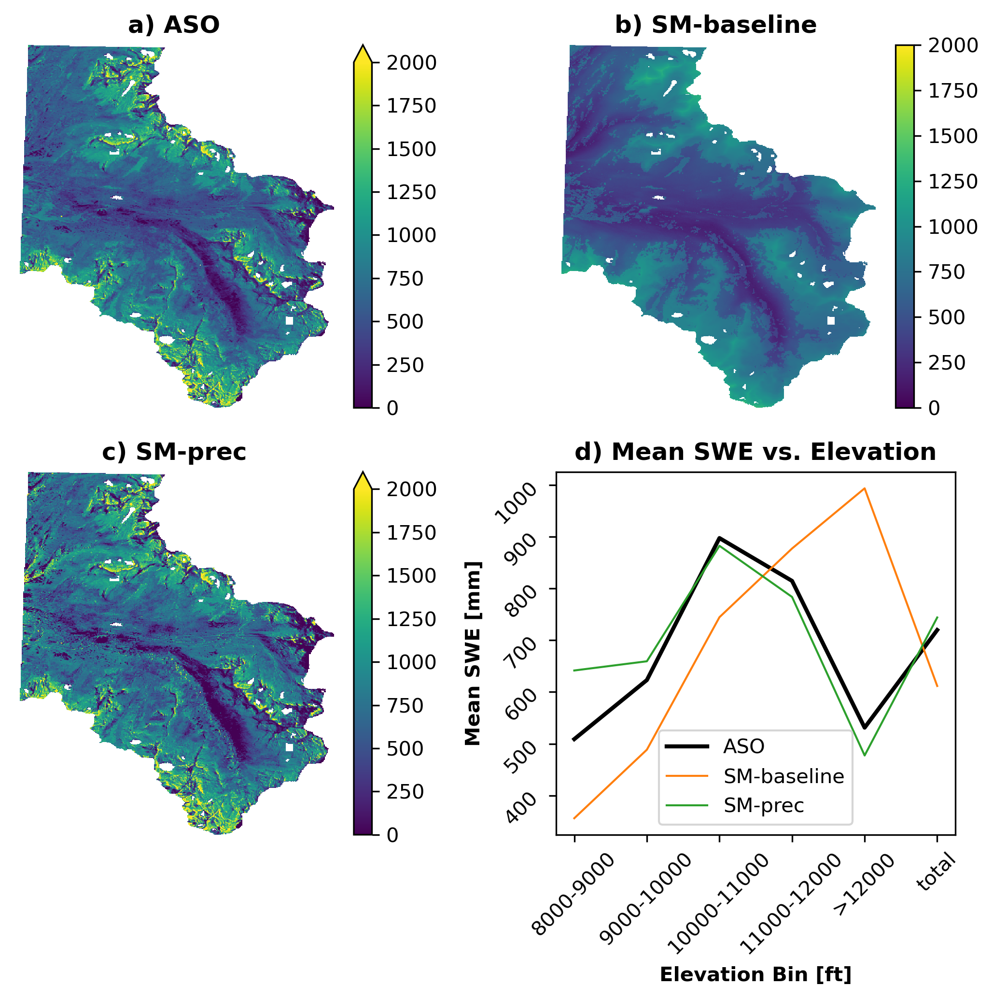

In [14]:
date = '2016-03-26'
dt = np.array(date,dtype = np.datetime64)
mean_aso = []
mean_sm_b = []
mean_sm_c = []
for elev in range(0,dem_clip_da.elev.shape[0]):
    mean_aso.append(float(aso_clip_da.where(aso_clip_da.date == np.datetime64(date),drop = True).where(~dem_clip_da[elev].isnull()).mean().values))
    mean_sm_b.append(float(sm_ml_Biased_clip_da.where(sm_ml_Biased_clip_da.date == np.datetime64(date),drop = True).where(~dem_clip_da[elev].isnull()).mean().values))
    mean_sm_c.append(float(sm_ml_Corrected_clip_da.where(sm_ml_Corrected_clip_da.date == np.datetime64(date),drop = True).where(~dem_clip_da[elev].isnull()).mean().values))
fig,ax = plt.subplots(2,2,figsize = (7,7),dpi = 300)
ax[1][1].plot(dem_clip_da.elev.values,np.array(mean_aso) * 1000,label = 'ASO',color = 'black',linewidth = 2)
ax[1][1].plot(dem_clip_da.elev.values,np.array(mean_sm_b)* 1000,label = 'SM-baseline',color = 'C1',linewidth = 1)
ax[1][1].plot(dem_clip_da.elev.values,np.array(mean_sm_c)* 1000,label = 'SM-prec',color = 'C2',linewidth = 1)
a = (aso_clip_da.where(aso_clip_da.date == dt,drop = True) * 1000).plot(ax=ax[0][0],vmin = 0,vmax = 2000)
a.colorbar.set_label("")
b = (sm_ml_Biased_clip_da.where(sm_ml_Biased_clip_da.date == np.datetime64(date),drop = True)[0]*1000).plot(ax=ax[0][1],vmin = 0,vmax = 2000)
c = (sm_ml_Corrected_clip_da.where(sm_ml_Corrected_clip_da.date == np.datetime64(date),drop = True)[0]*1000).plot(ax=ax[1][0],vmin = 0,vmax = 2000)
b.colorbar.set_label("")
c.colorbar.set_label("")
ax[0][0].axis('off')
ax[0][1].axis('off')
ax[1][0].axis('off')
ax[1][1].set_title('d) Mean SWE vs. Elevation',fontweight = 'bold')
ax[0][0].set_title('a) ASO',fontweight = 'bold')
ax[0][1].set_title('b) SM-baseline',fontweight = 'bold')
ax[1][0].set_title('c) SM-prec',fontweight = 'bold')
ax[1][1].set_ylabel('Mean SWE [mm]',fontweight = 'bold')
ax[1][1].set_xlabel('Elevation Bin [ft]',fontweight = 'bold')
# plt.suptitle(date,fontweight = 'bold')
ax[1][1].tick_params(labelrotation=45)
ax[1][1].legend()
plt.tight_layout()
# plt.show()
plt.savefig('./pngs/S6_TUOL_Precip_Bias_correction.png',dpi=300)
plt.show()

# Appendix

## ASO ASO Dates

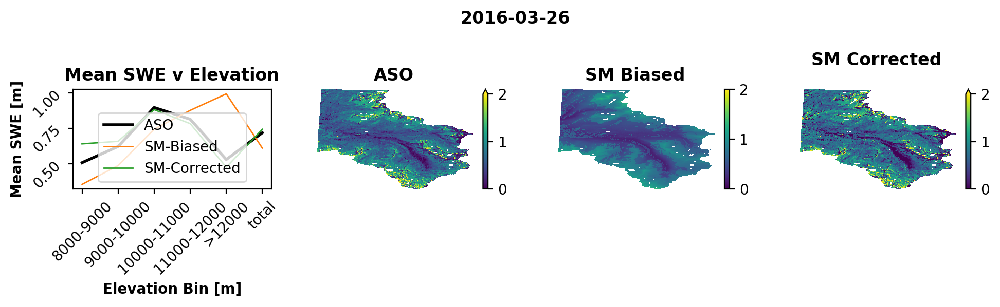

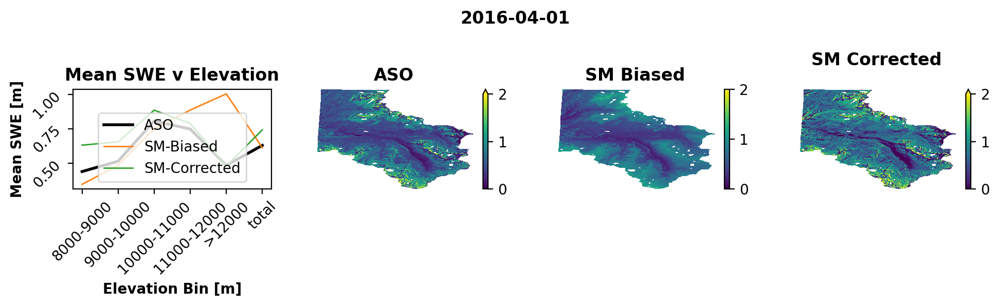

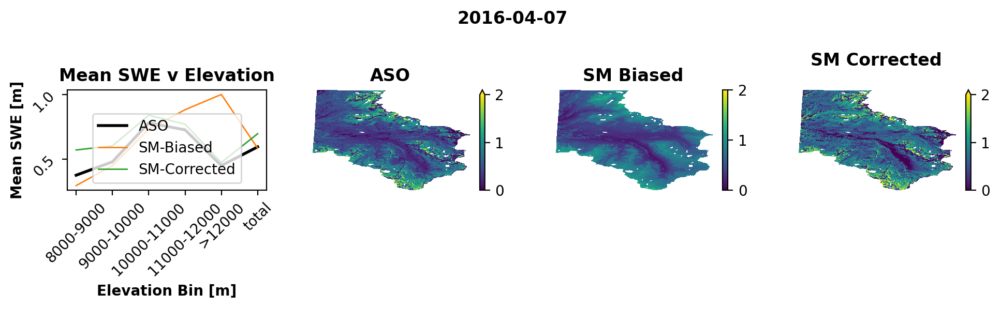

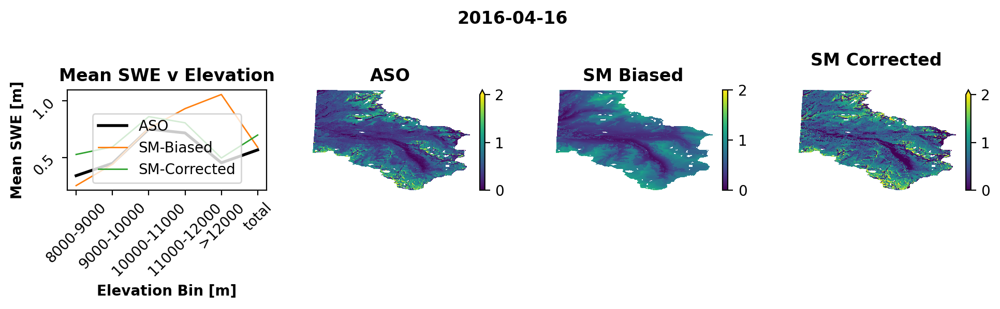

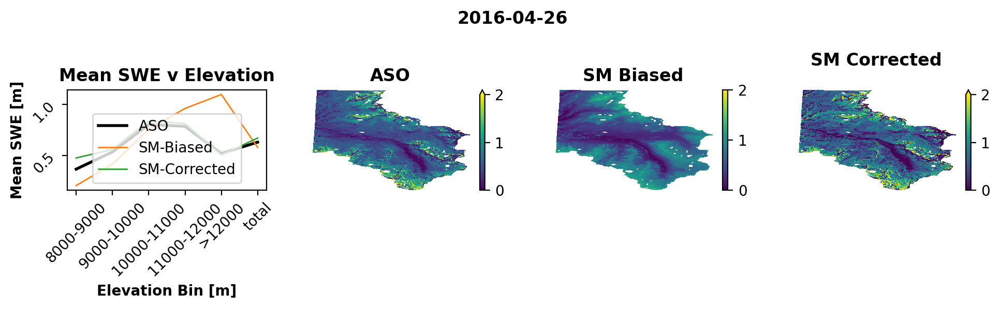

...

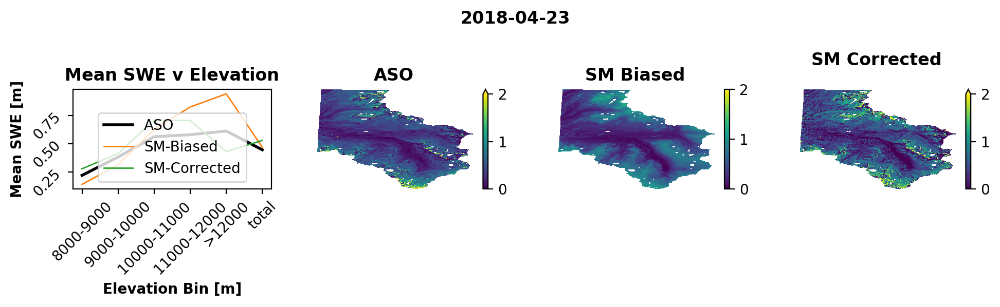

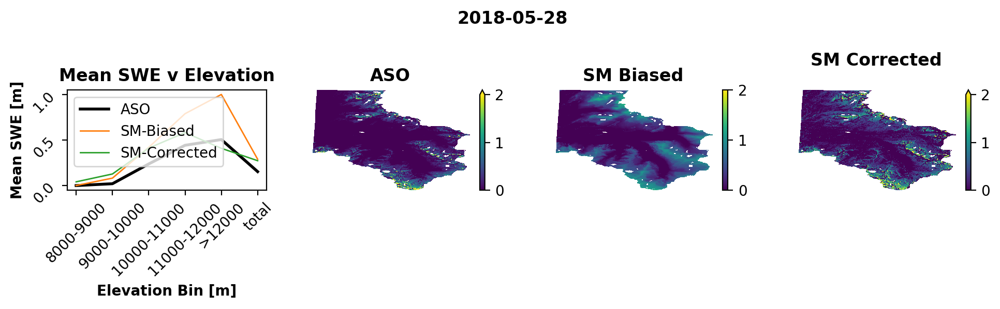

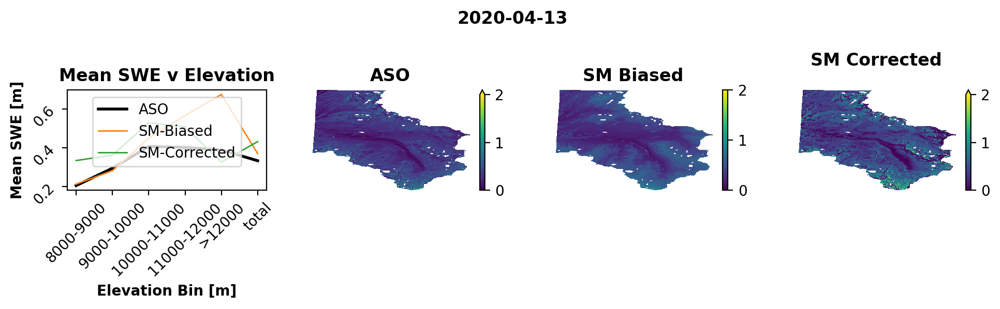

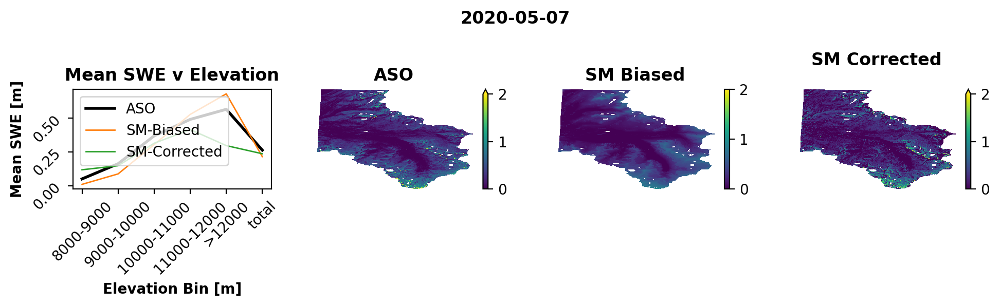

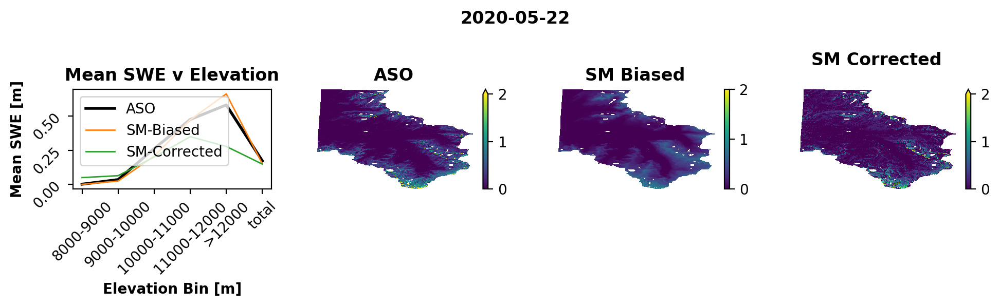

In [31]:
for dt in sm_ml_Biased_clip_da.date.values:
    date = str(dt)[0:10]
    mean_aso = []
    mean_sm_b = []
    mean_sm_c = []
    for elev in range(0,dem_clip_da.elev.shape[0]):
        mean_aso.append(float(aso_clip_da.where(aso_clip_da.date == np.datetime64(date),drop = True).where(~dem_clip_da[elev].isnull()).mean().values))
        mean_sm_b.append(float(sm_ml_Biased_clip_da.where(sm_ml_Biased_clip_da.date == np.datetime64(date),drop = True).where(~dem_clip_da[elev].isnull()).mean().values))
        mean_sm_c.append(float(sm_ml_Corrected_clip_da.where(sm_ml_Corrected_clip_da.date == np.datetime64(date),drop = True).where(~dem_clip_da[elev].isnull()).mean().values))
    fig,ax = plt.subplots(1,4,figsize = (10,3),dpi = 200)
    ax[0].plot(dem_clip_da.elev.values,np.array(mean_aso),label = 'ASO',color = 'black',linewidth = 2)
    ax[0].plot(dem_clip_da.elev.values,np.array(mean_sm_b),label = 'SM-Biased',color = 'C1',linewidth = 1)
    ax[0].plot(dem_clip_da.elev.values,np.array(mean_sm_c),label = 'SM-Corrected',color = 'C2',linewidth = 1)
    a = aso_clip_da.where(aso_clip_da.date == dt,drop = True).plot(ax=ax[1],vmin = 0,vmax = 2.0)
    a.colorbar.set_label("")
    b = sm_ml_Biased_clip_da.where(sm_ml_Biased_clip_da.date == np.datetime64(date),drop = True)[0].plot(ax=ax[2],vmin = 0,vmax = 2.0)
    c = sm_ml_Corrected_clip_da.where(sm_ml_Corrected_clip_da.date == np.datetime64(date),drop = True)[0].plot(ax=ax[3],vmin = 0,vmax = 2.0)
    b.colorbar.set_label("")
    c.colorbar.set_label("")
    ax[1].axis('off')
    ax[2].axis('off')
    ax[3].axis('off')
    ax[0].set_title('Mean SWE v Elevation',fontweight = 'bold')
    ax[1].set_title('ASO',fontweight = 'bold')
    ax[2].set_title('SM Biased',fontweight = 'bold')
    ax[3].set_title('SM Corrected',fontweight = 'bold')
    ax[0].set_ylabel('Mean SWE [m]',fontweight = 'bold')
    ax[0].set_xlabel('Elevation Bin [m]',fontweight = 'bold')
    plt.suptitle(date,fontweight = 'bold')
    ax[0].tick_params(labelrotation=45)
    ax[0].legend()
    plt.tight_layout()
    plt.show()
    